# Setup

In [1]:
%%capture
# Catch warnings
import warnings

# Maths functions
from numpy import (sort, mean, std, argmax, arange)

# Data manipulation
import pandas as pd
import numpy as np

# Statistical analysis
from scipy.stats import f_oneway

# Data visualization 
import matplotlib as mp
import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib.style as style
import matplotlib.font_manager as font_manager
style.use('ggplot')
%matplotlib inline

import seaborn as sns
sns.set_context('talk')

# Model development
import sklearn
from sklearn.preprocessing import (StandardScaler, LabelEncoder, OrdinalEncoder, OneHotEncoder)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Model selection and evaluation
from sklearn.model_selection import (train_test_split, cross_val_score, RepeatedStratifiedKFold) 
import optuna
from yellowbrick.classifier import (ConfusionMatrix, DiscriminationThreshold)
from sklego.meta import Thresholder
from sklearn.metrics import (make_scorer, accuracy_score,  roc_auc_score,roc_curve, 
                             precision_recall_curve, average_precision_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, precision_score, recall_score, fbeta_score) 

# Feature Importance
import shap

# Save model
import joblib

# Set notebook options
pd.set_option("display.max_columns", None)
pd.set_option('display.max_colwidth', 100)
pd.set_option("display.max_rows", 10000)
pd.set_option("display.float_format", lambda x: '%.2f' % x)

# Pretty display of multiple functions in a cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Set random state
RANDOM_STATE = 2021

# Analysis
## The Problem Size

C:\Users\yvett\AppData\Local\Temp\ipykernel_57044\3724244391.py:9: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax1 = plt.subplot(gs[0])


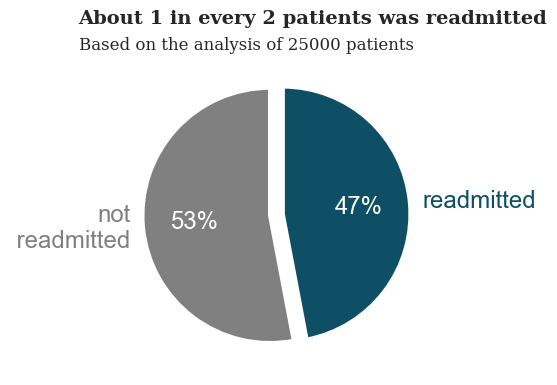

In [2]:
df = pd.read_csv('../data/raw/hospital_readmissions.csv')

df['counter'] = 1
readmission_prop = df[['readmitted', 'counter']].groupby(['readmitted']).count()/df.shape[0] 

fig = plt.subplots(figsize=(10, 4))
gs= gridspec.GridSpec(1,2, width_ratios=[2,2])

ax1 = plt.subplot(gs[0])

patches, texts, pcts = ax1.pie(readmission_prop['counter'],
        labels = ['not\n readmitted', 'readmitted'],
        autopct='%0.0f%%',
        colors = ('gray', '#0e4f66'),
    wedgeprops={'linewidth': 3.0, 'edgecolor': 'white'},
    textprops={'size': 'x-large'},
    startangle=90,
    explode=(0, 0.1))

for i, patch in enumerate(patches):
  texts[i].set_color(patch.get_facecolor())
plt.setp(pcts, color='white')
plt.setp(texts, fontweight=50)

ax1.text(-1.5, 1.5, 'About 1 in every 2 patients was readmitted', fontsize=14, fontweight='bold', fontfamily='serif')
ax1.text(-1.5, 1.30,'Based on the analysis of 25000 patients',fontfamily='serif',fontsize=12)

plt.tight_layout()
plt.savefig('../reports/figures/target distribution.png', bbox_inches='tight')
plt.show();

## Key Insight 1

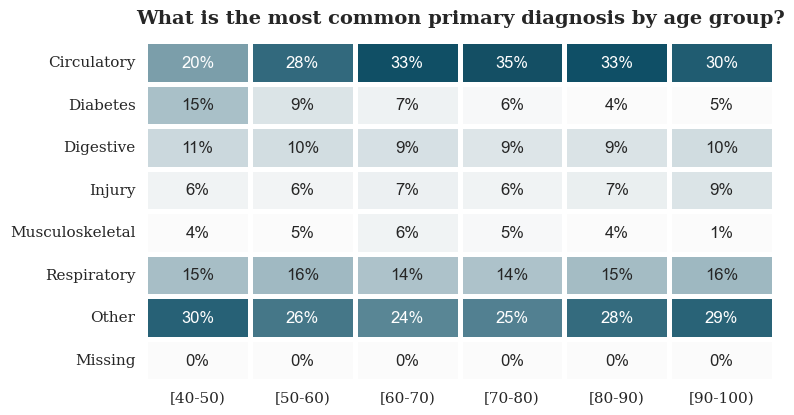

In [3]:
df['age_o'] = pd.Categorical(df['age'], ['[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)'])

df['diag_1_o'] = pd.Categorical(df['diag_1'], ['Circulatory', 'Diabetes', 'Digestive', 'Injury', 'Musculoskeletal', 'Respiratory', 'Other', 'Missing'])

df_heatmap1 = pd.crosstab(df['age_o'],df['diag_1_o'],normalize = "index").T

colors = ["#fbfbfb", "#0e4f66", "#4b4b4c"]
colormap = mp.colors.LinearSegmentedColormap.from_list("", colors)

fig, ax = plt.subplots(figsize=(8, 4))

sns.heatmap(df_heatmap1,cmap=colormap,square=False, linewidth=2.5,cbar=False,
            annot=True,fmt='1.0%',vmax=.6,vmin=0.05,ax=ax,annot_kws={"fontsize":12})

ax.spines['top'].set_visible(False)


fig.text(0.18, 1, 'What is the most common primary diagnosis by age group?', fontweight='bold', fontfamily='serif', fontsize=14)

ax.set_yticklabels(ax.get_yticklabels(), fontfamily='serif', rotation = 0, fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), fontfamily='serif', rotation=0, fontsize=11)

ax.set_ylabel('')    
ax.set_xlabel('')
ax.tick_params(axis=u'both', which=u'both',length=0)

plt.tight_layout()
plt.savefig('../reports/figures/primary diagnosis by age group.png', bbox_inches='tight')
plt.show();

- "Circulatory" diagnosis is the most common primary diagnosis of patients aged 50 years and above.
- Patients aged under 50 years, were diagnosed with "Other" as the most common primary diagnosis.

## Key Insight 2
### A diagnosis of Diabetes was not found to influence readmission rates

A patient could never be diagnosed with diabetes or could be diagnosed with diabetes up to at most three times.

A hypothesis test to investigate the effect of diabetes diagnosis on hospital readmissions at a significance level of 0.05:

- Null hypothesis (H0) : A diagnosis of diabetes is not correlated with hospital readmission
- Alternative hypothesis (H1) : A diagnosis of diabetes is correlated with hospital readmission

In [4]:
num_cols = list(df.select_dtypes(include=['float64', 'int64']).columns)

def check_category_numerical_correlation(_df, cat_col, num_cols):
    '''Anova hypothesis testing assumptions:
        
    Null hypothesis(H0): The variables are not correlated with each other
    P-value: The probability of Null hypothesis being true
    Accept Null hypothesis if P-value>0.05. Means variables are NOT correlated
    Reject Null hypothesis if P-value<0.05. Means variables are correlated
   
    '''

    col_list = []
    anova_pval_list = []
    
    for col in num_cols:
        category_grp_list=_df.groupby(cat_col)[col].apply(list)
    
        anova_results = f_oneway(*category_grp_list)
        anova_pval_list.append(anova_results[1])
        col_list.append(col)
        
    _df_results = pd.DataFrame(list(zip(col_list, anova_pval_list)), columns=['Variable', 'P-value'])   
    df_final = _df_results.sort_values(['P-value']).reset_index(drop=True)
    
    return df_final

isY = lambda x:int(x=='Diabetes')

countNumberOfDiabetesDiag = lambda row: isY(row['diag_1']) + isY(row['diag_2']) + isY(row['diag_3'])

df['n_diabetes_diag'] = df.apply(countNumberOfDiabetesDiag,axis=1)

num_cols = ['n_diabetes_diag',
            'time_in_hospital',
 'n_lab_procedures',
 'n_procedures',
 'n_medications',
 'n_outpatient',
 'n_inpatient',
 'n_emergency']

colors = ["lightgray","lightgray","#0e4f66"]
colormap = mp.colors.LinearSegmentedColormap.from_list("", colors)

num_corr_check = check_category_numerical_correlation(df, 'readmitted', num_cols)
num_corr_check.style.set_properties(**{'text-align': 'center'}).format({'P-value': "{:.2f}"}).background_gradient(cmap=colormap)

,Variable,P-value
0,n_inpatient,0.00
1,n_outpatient,0.00
2,n_emergency,0.00
3,n_procedures,0.00
4,time_in_hospital,0.00
5,n_medications,0.00
6,n_lab_procedures,0.00
7,n_diabetes_diag,0.53


- The p-value (0.53) from the hypothesis test is greater than the significance level of 0.05. We accept the Null Hypothesis that diagnosis of diabetes is not correlated with hospital readmission.

## Feature Distribution

In [5]:
df.describe()

,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,counter,n_diabetes_diag
count,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00
mean,4.45,43.24,1.35,16.25,0.37,0.62,0.19,1.00,0.36
std,3.00,19.82,1.72,8.06,1.20,1.18,0.89,0.00,0.49
min,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00
25%,2.00,31.00,0.00,11.00,0.00,0.00,0.00,1.00,0.00
50%,4.00,44.00,1.00,15.00,0.00,0.00,0.00,1.00,0.00
75%,6.00,57.00,2.00,20.00,0.00,1.00,0.00,1.00,1.00
max,14.00,113.00,6.00,79.00,33.00,15.00,64.00,1.00,3.00


In [6]:
cols_object=[(col, df[col].unique()) for col in df.columns if df[col].dtype=='object']
pd.DataFrame(cols_object)

,0,1
0,age,"[[70-80), [50-60), [60-70), [40-50), [80-90), [90-100)]"
1,medical_specialty,"[Missing, Other, InternalMedicine, Family/GeneralPractice, Cardiology, Surgery, Emergency/Trauma]"
2,diag_1,"[Circulatory, Other, Injury, Digestive, Respiratory, Diabetes, Musculoskeletal, Missing]"
3,diag_2,"[Respiratory, Other, Circulatory, Injury, Diabetes, Digestive, Musculoskeletal, Missing]"
4,diag_3,"[Other, Circulatory, Diabetes, Respiratory, Injury, Musculoskeletal, Digestive, Missing]"
5,glucose_test,"[no, normal, high]"
6,A1Ctest,"[no, normal, high]"
7,change,"[no, yes]"
8,diabetes_med,"[yes, no]"
9,readmitted,"[no, yes]"
